<a href="https://colab.research.google.com/github/sarthakkalra/ml-assessment-sarthak-kalra/blob/main/part_a%5Cq2_unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset (correct raw link)
url = 'https://raw.githubusercontent.com/sarthakkalra/ml-assessment-sarthak-kalra/main/data/q2_customers.csv'
df = pd.read_csv(url)

# Basic inspection
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Select features
features = ['age', 'annual_spend', 'visits_per_month',
            'basket_size', 'days_since_last_visit',
            'num_categories_purchased']

X = df[features]

# Handle missing values
X = X.fillna(X.median())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=features)

df_scaled.head()

Shape: (500, 6)

Missing Values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Essential for K-Means

K-Means clustering relies on the **Euclidean distance** between data points to assign them to clusters. Features with larger numerical ranges (e.g., `annual_spend` which might be in the thousands) will dominate the distance calculation over features with smaller ranges (e.g., `visits_per_month` which might be single digits).

Scaling ensures that all features contribute equally to the distance metric, preventing the algorithm from being biased toward high-magnitude features.

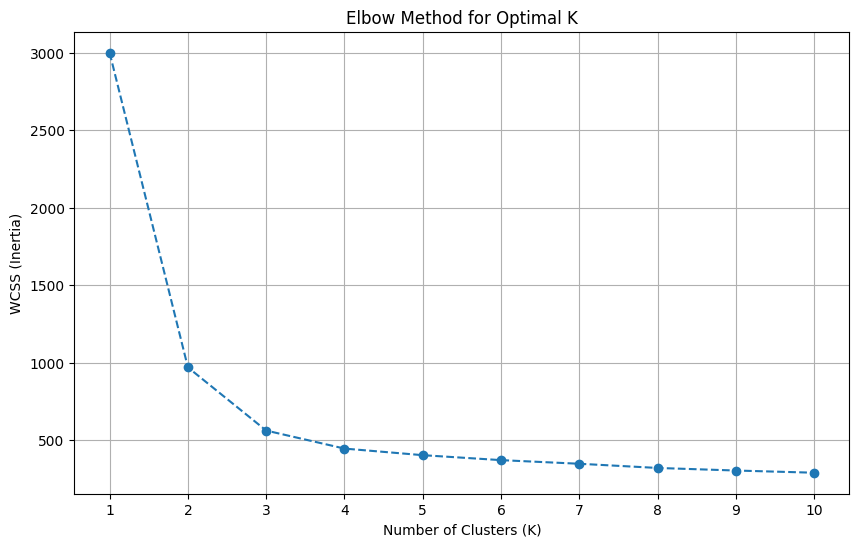

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [12]:
import pandas as pd
from sklearn.cluster import KMeans

# Choosing K=3 based on the Elbow Method
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column to original dataframe
df['cluster'] = clusters

# Calculate centroids in original scale for interpretation
centroids = df.groupby('cluster')[features].mean()
print("Cluster Centroids (Mean values):")
display(centroids)

Cluster Centroids (Mean values):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Business Interpretation of Clusters

Based on the mean feature values for each cluster, we can categorize the segments as follows:

*   **Cluster 0: Young Frequent Shoppers.** These customers are younger (avg. age ~25) and visit most frequently (~14 times/month) but have the lowest annual spend and smallest basket sizes. They shop across fewer categories and visit very recently.
*   **Cluster 1: High-Value Occasional Shoppers.** This group consists of older individuals (avg. age ~57) with the highest annual spend (~$89k) and very large basket sizes. However, they visit infrequently and haven't shopped in a long time (~105 days), suggesting they make major, bulk purchases.
*   **Cluster 2: Mid-Range Regulars.** Middle-aged customers (avg. age ~40) with moderate spending and visit frequency. They represent a balanced middle ground in terms of loyalty and purchasing power.

In [13]:
from sklearn.decomposition import PCA
import pandas as pd

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Print explained variance ratio
print("Explained Variance Ratio:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")

# Print feature loadings as a DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("\nFeature Loadings:")
display(loadings)

Explained Variance Ratio:
PC1: 0.8356
PC2: 0.0557

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


### Interpretation of PCA Components

*   **PC1 (83.56% Variance): Overall Customer Engagement/Value.**
    *   PC1 has high positive loadings for `age`, `annual_spend`, `basket_size`, and `num_categories_purchased`, and a strong negative loading for `visits_per_month`.
    *   This component differentiates between older, high-spending "bulk" shoppers (positive PC1) and younger, frequent "convenience" shoppers (negative PC1).

*   **PC2 (5.57% Variance): Purchase Recency.**
    *   PC2 is almost entirely dominated by `days_since_last_visit` (loading of 0.91).
    *   This component specifically captures how long it has been since a customer's last interaction, independent of their total spending or age profile.

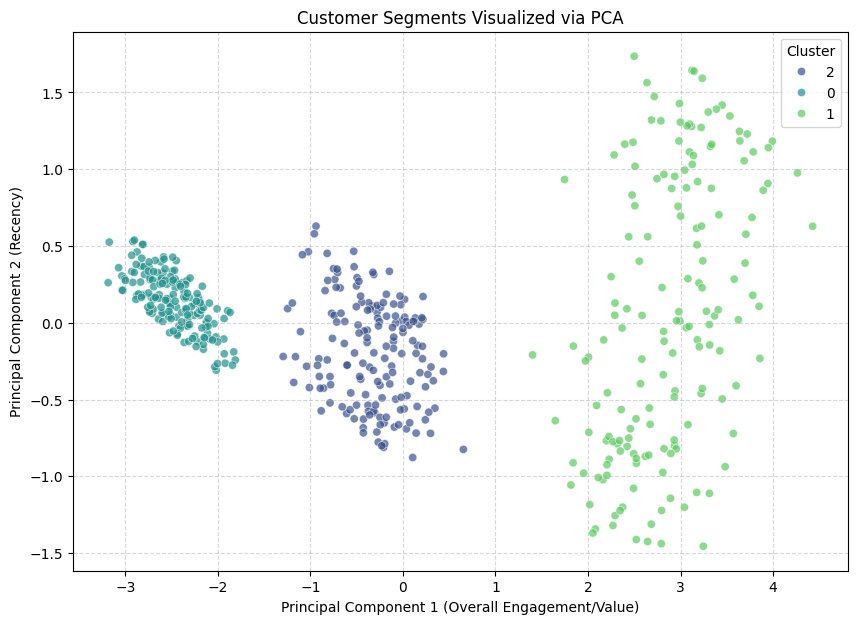

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for visualization
pca_df = pd.DataFrame(
    data=pca_data,
    columns=['PC1', 'PC2']
)
pca_df['Cluster'] = df['cluster'].astype(str)

# Plot the clusters using PC1 and PC2
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    alpha=0.7
)

plt.title('Customer Segments Visualized via PCA')
plt.xlabel('Principal Component 1 (Overall Engagement/Value)')
plt.ylabel('Principal Component 2 (Recency)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()